# Forest Cover Type — entraînement de 3 modèles de classification
Objectif : prédire `Cover_Type` (7 types de couverture forestière) à partir de variables topographiques et de sol.
Modèles comparés : **régression logistique multinomiale**, **Random Forest**, **KNN** — métriques : accuracy et F1 (macro).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
# Palette catégorielle (ordre fixe, une couleur par classe)
PALETTE = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7']
COVER_NAMES = {1: 'Spruce/Fir', 2: 'Lodgepole Pine', 3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
               5: 'Aspen', 6: 'Douglas-fir', 7: 'Krummholz'}
sns.set_theme(style='whitegrid')

## 1. Chargement et aperçu

In [2]:
train = pd.read_csv('train (1).csv')
test = pd.read_csv('test-full (1).csv')  # non labellisé : servira pour les prédictions finales
print('train :', train.shape, '| test :', test.shape)
train.head()

train : (15120, 56) | test : (581012, 55)


,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,242642,2881,130,22,210,54,1020,250,221,88,...,0,0,0,0,0,0,0,0,0,1
1,309891,3005,351,14,242,-16,1371,194,215,159,...,0,0,0,0,0,0,0,0,0,1
2,287847,3226,63,14,618,2,1092,232,210,107,...,0,0,0,0,0,0,0,0,0,1
3,516307,3298,317,8,661,60,752,198,233,174,...,0,0,0,0,0,0,0,0,0,1
4,124860,3080,35,6,175,26,3705,219,227,144,...,0,0,0,0,0,0,0,0,0,1


In [3]:
train.info(verbose=False)
train.describe().T.head(11)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Columns: 56 entries, Id to Cover_Type
dtypes: int64(56)
memory usage: 6.5 MB


,count,mean,std,min,25%,50%,75%,max
Id,15120.0,267008.526389,179261.722330,5.0,103705.0,276034.5,398150.25,581005.0
Elevation,15120.0,2748.649934,419.009589,1877.0,2373.0,2754.0,3109.00,3850.0
Aspect,15120.0,155.834524,109.745372,0.0,65.0,125.0,257.00,360.0
Slope,15120.0,16.556746,8.534602,0.0,10.0,15.0,22.00,50.0
Horizontal_Distance_To_Hydrology,15120.0,228.376521,209.196381,0.0,67.0,180.0,330.00,1376.0
Vertical_Distance_To_Hydrology,15120.0,51.311706,61.520488,-135.0,5.0,32.0,80.00,570.0
Horizontal_Distance_To_Roadways,15120.0,1717.977712,1330.263450,0.0,760.0,1315.0,2292.00,6803.0
Hillshade_9am,15120.0,213.028836,30.638406,52.0,197.0,220.0,236.00,254.0
Hillshade_Noon,15120.0,218.865741,22.797288,99.0,207.0,223.0,235.00,254.0
Hillshade_3pm,15120.0,134.477116,46.070054,0.0,106.0,138.0,166.00,251.0


## 2. Vérification et nettoyage

In [4]:
TARGET = 'Cover_Type'
wild_cols = [c for c in train if c.startswith('Wilderness_Area')]
soil_cols = [c for c in train if c.startswith('Soil_Type')]
num_cols = [c for c in train if c not in wild_cols + soil_cols + ['Id', TARGET]]

print('Valeurs manquantes (train / test) :', train.isna().sum().sum(), '/', test.isna().sum().sum())
print('Doublons (hors Id) :', train.drop(columns='Id').duplicated().sum())
# Les variables one-hot doivent avoir exactement un 1 par ligne
print('One-hot Wilderness valide :', (train[wild_cols].sum(axis=1) == 1).all())
print('One-hot Soil valide       :', (train[soil_cols].sum(axis=1) == 1).all())
const_cols = [c for c in train if train[c].nunique() == 1]
print('Colonnes constantes :', const_cols)

Valeurs manquantes (train / test) : 0 / 0
Doublons (hors Id) : 0
One-hot Wilderness valide : True
One-hot Soil valide       : True
Colonnes constantes : ['Soil_Type15']


In [5]:
# Id n'est qu'un identifiant ; les colonnes constantes n'apportent aucune information
train_clean = train.drop(columns=['Id'] + const_cols)
soil_cols = [c for c in soil_cols if c not in const_cols]
feature_cols = num_cols + wild_cols + soil_cols
print('Features retenues :', len(feature_cols))

Features retenues : 53


## 3. Visualisations

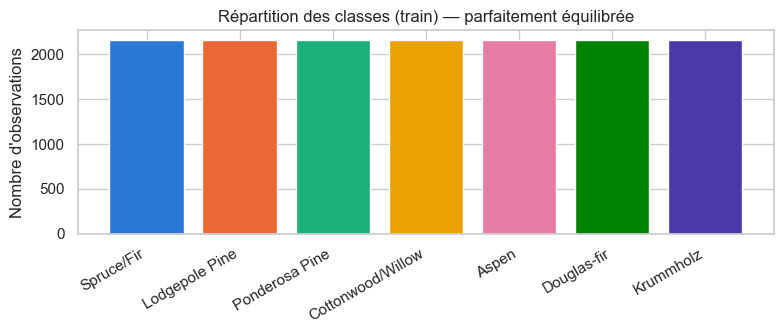

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
counts = train_clean[TARGET].value_counts().sort_index()
ax.bar([COVER_NAMES[i] for i in counts.index], counts.values, color=PALETTE)
ax.set_title('Répartition des classes (train) — parfaitement équilibrée')
ax.set_ylabel("Nombre d'observations")
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

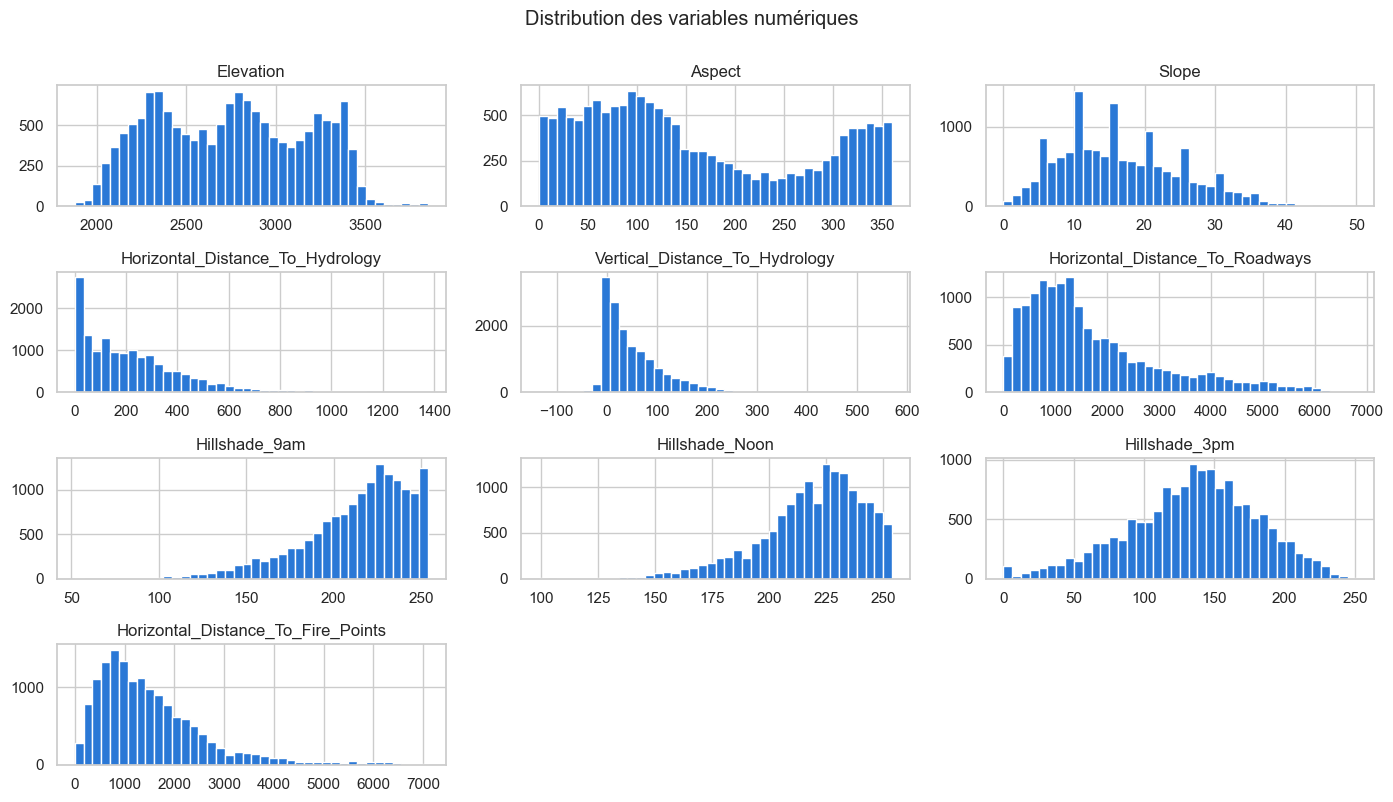

In [7]:
train_clean[num_cols].hist(bins=40, figsize=(14, 8), color=PALETTE[0], edgecolor='white')
plt.suptitle('Distribution des variables numériques', y=1.0); plt.tight_layout(); plt.show()

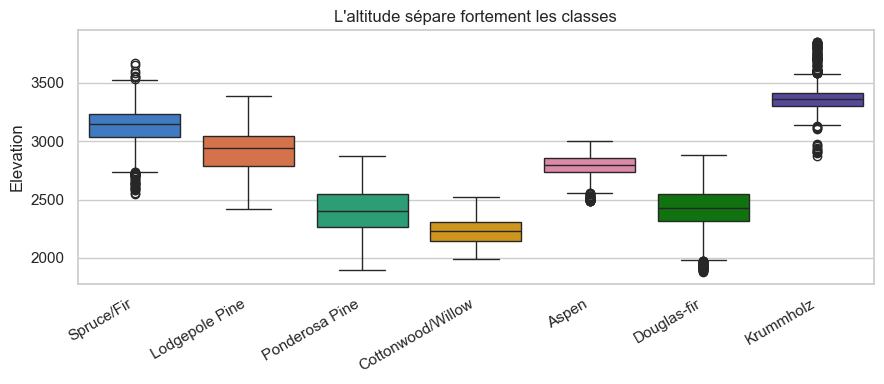

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=train_clean.assign(Cover=train_clean[TARGET].map(COVER_NAMES)),
            x='Cover', y='Elevation', hue='Cover', palette=PALETTE, legend=False, ax=ax)
ax.set_title("L'altitude sépare fortement les classes"); ax.set_xlabel('')
plt.xticks(rotation=30, ha='right'); plt.tight_layout(); plt.show()

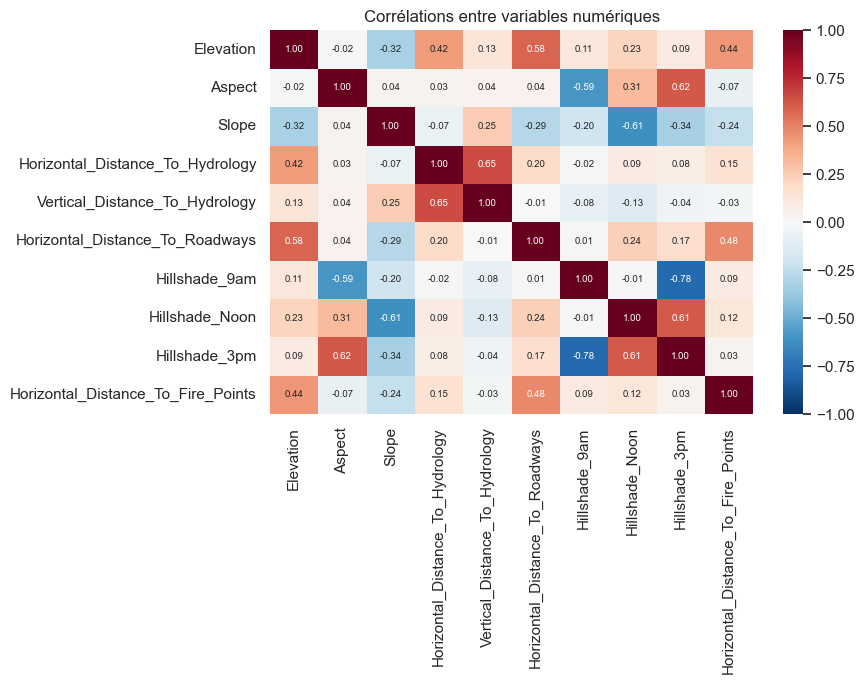

In [9]:
plt.figure(figsize=(9, 7))
sns.heatmap(train_clean[num_cols].corr(), cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Corrélations entre variables numériques'); plt.tight_layout(); plt.show()

## 4. Split train / validation et standardisation
Le test fourni n'a pas de labels : on découpe le train en 80 % entraînement / 20 % validation (stratifié).
La standardisation (`StandardScaler`) ne s'applique qu'aux variables continues — les colonnes binaires restent telles quelles.
Elle est placée dans un `Pipeline` pour être ajustée uniquement sur la partie entraînement (pas de fuite de données).

In [10]:
X = train_clean[feature_cols]
y = train_clean[TARGET]
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

preprocess = ColumnTransformer([('scale', StandardScaler(), num_cols)], remainder='passthrough')
print(X_train.shape, X_val.shape)
pd.DataFrame(preprocess.fit_transform(X_train)[:, :len(num_cols)], columns=num_cols).describe().loc[['mean', 'std']].round(2)

(12096, 53) (3024, 53)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points
mean,0.0,-0.0,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 5. Entraînement des modèles

In [11]:
models = {
    'Régression logistique': LogisticRegression(max_iter=2000),
    'Random Forest': RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5),
}

results, fitted = [], {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocess), ('model', model)]).fit(X_train, y_train)
    fitted[name] = pipe
    pred_tr, pred_val = pipe.predict(X_train), pipe.predict(X_val)
    results.append({
        'Modèle': name,
        'Accuracy train': accuracy_score(y_train, pred_tr),
        'Accuracy val': accuracy_score(y_val, pred_val),
        'F1 macro val': f1_score(y_val, pred_val, average='macro'),
    })

results = pd.DataFrame(results).set_index('Modèle').sort_values('F1 macro val', ascending=False)
results.round(4)

,Accuracy train,Accuracy val,F1 macro val
Modèle,,,
Random Forest,1.0000,0.8618,0.8604
KNN (k=5),0.8585,0.7751,0.7709
Régression logistique,0.7062,0.7073,0.7034


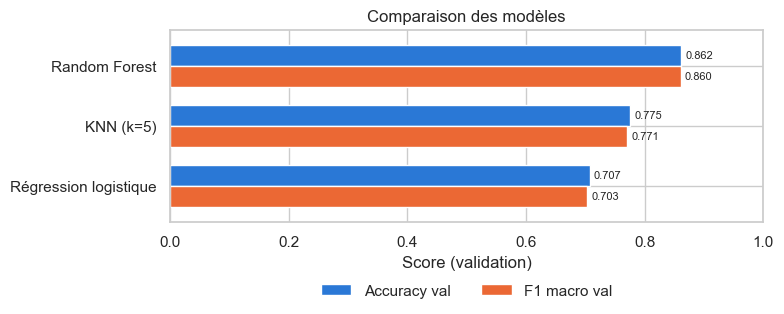

In [12]:
ax = results[['Accuracy val', 'F1 macro val']].plot.barh(figsize=(8, 3.5), color=PALETTE[:2], width=0.7)
ax.set_xlim(0, 1); ax.set_xlabel('Score (validation)'); ax.set_ylabel('')
ax.set_title('Comparaison des modèles'); ax.invert_yaxis()
for c in ax.containers: ax.bar_label(c, fmt='%.3f', padding=3, fontsize=8)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False); plt.tight_layout(); plt.show()

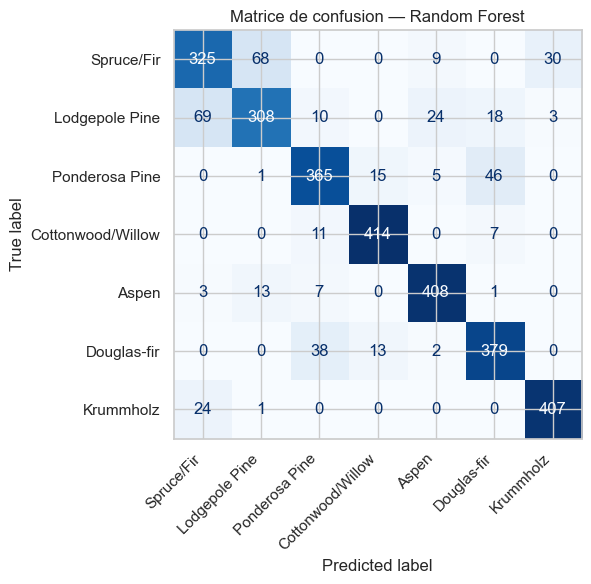

In [13]:
best = results.index[0]
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_estimator(fitted[best], X_val, y_val, cmap='Blues', ax=ax,
                                      display_labels=list(COVER_NAMES.values()), colorbar=False)
ax.set_title(f'Matrice de confusion — {best}')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## Conclusion
- Données propres : aucune valeur manquante, aucun doublon, encodage one-hot cohérent ; `Id` et `Soil_Type15` (constante) retirés.
- Le **Random Forest** domine (il capte les interactions non linéaires, notamment autour de l'altitude) ; le KNN profite de la standardisation ; la régression logistique, linéaire, plafonne plus bas.
- L'écart train/val du Random Forest montre du sur-apprentissage : piste d'amélioration via tuning (`max_depth`, `min_samples_leaf`) et validation croisée avant de prédire sur `test-full`.